In [1]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rxr
import pickle
from astropy.time import Time

### Load ICESat-2 data downloaded in Grand Mesa Demo:

In [2]:
atl06sr_gdf = pickle.load(open('../data/temp/atl06_sr_10m_sierras_concat_sorted.pkl', 'rb'))
atl06sr_gdf

,y_atc,x_atc,w_surface_window_final,cycle,segment_id,pflags,h_mean,spot,dh_fit_dx,region,...,segment_snowcover,segment_landcover,3dep.time,3dep.flags,3dep.value,3dep.file_id,beam_azimuth,segment_watermask,urban_flag,time_acq
time,,,,,,,,,,,,,,,,,,,,,
2021-10-12 07:30:24.762091008,-13058.768555,15763947.0,5.061572,13,787033,0,457.365481,6,0.197039,6,...,1.0,126.000000,1.354129e+09,0,456.924465,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.762091008
2021-10-12 07:30:24.759267328,-13058.611328,15763927.0,4.588598,13,787032,0,453.521283,6,0.178340,6,...,1.0,126.000000,1.354129e+09,0,455.139631,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.759267328
2021-10-12 07:30:24.753623040,-13058.166992,15763887.0,3.000000,13,787030,0,449.772409,6,0.033152,6,...,1.0,126.000000,1.354129e+09,0,450.054189,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.753623040
2021-10-12 07:30:24.750803456,-13057.912109,15763867.0,3.000000,13,787029,0,449.011704,6,0.041241,6,...,1.0,126.000000,1.354129e+09,0,449.304423,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.750803456
2021-10-12 07:30:24.747986176,-13057.662109,15763847.0,3.000000,13,787028,0,448.236828,6,0.034019,6,...,1.0,126.000000,1.354129e+09,0,448.442536,51539607552,NaN,NaN,NaN,2021-10-12 07:30:24.747986176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-10-14 00:50:23.212469760,2780.628906,15580344.0,3.000000,9,777873,0,1337.363153,3,0.084668,6,...,1.0,30.000000,1.354129e+09,0,1337.397759,287762808832,NaN,NaN,NaN,2020-10-14 00:50:23.212469760
2020-10-14 00:50:23.209665792,2780.615723,15580324.0,3.000000,9,777872,0,1335.522249,3,0.096522,6,...,1.0,25.163657,1.354129e+09,0,1336.374309,287762808832,NaN,NaN,NaN,2020-10-14 00:50:23.209665792
2020-10-14 00:50:23.206865920,2780.604736,15580304.0,3.230203,9,777871,0,1333.307045,3,0.124384,6,...,1.0,20.000000,1.354129e+09,0,1334.484403,287762808832,NaN,NaN,NaN,2020-10-14 00:50:23.206865920


In [3]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

### Load reanalysis data for the fsca:

In [4]:
reanalysis_2021 = xr.open_dataset('../data/reanalysis/reanalysis_sierras_processed_2021.nc')

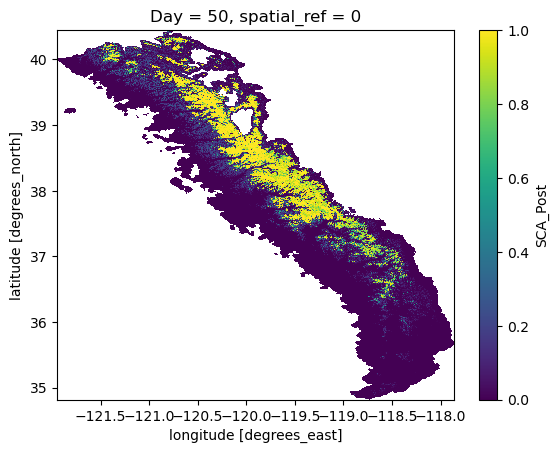

In [68]:
reanalysis_2021.SCA_Post[50].plot()

In [5]:
import datetime

def day_of_year(date):
    # Check if it's a leap year
    leap_year = date.year % 4 == 0 and (date.year % 100 != 0 or date.year % 400 == 0)
    
    # Define days in each month, accounting for leap year
    days_in_month = [31, 29 if leap_year else 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    
    # Calculate day of the year
    day_count = sum(days_in_month[i] for i in range(date.month - 1)) + date.day
    
    return day_count

# Example usage
date = datetime.date(2024, 5, 9)
print("Day of the year:", day_of_year(date))

Day of the year: 130


In [6]:
#Add DOY and DOWY column
def add_dowy(df, col=None):
    print("Adding Day of Water Year (DOWY)")
    if col is None:
        df['doy'] = df.index.dayofyear
        df['decyear'] = Time(df.index).decimalyear
    else:
        df['doy'] = pd.to_datetime(df[col]).dt.dayofyear
        df['decyear'] = Time(pd.to_datetime(df[col])).decimalyear
    
    #df['dowy'] = (df['doy'].index - pd.DateOffset(months=9)).dayofyear
    # Sept 30 is doy 273
    df['dowy'] = df['doy'] - 273
    df.loc[df['dowy'] <= 0, 'dowy'] += 365

In [7]:
add_dowy(atl06sr_gdf)

Adding Day of Water Year (DOWY)


In [8]:
atl06sr_gdf.columns

Index(['y_atc', 'x_atc', 'w_surface_window_final', 'cycle', 'segment_id',
       'pflags', 'h_mean', 'spot', 'dh_fit_dx', 'region', 'rms_misfit',
       'h_sigma', 'rgt', 'gt', 'n_fit_photons', 'geometry',
       'segment_snowcover', 'segment_landcover', '3dep.time', '3dep.flags',
       '3dep.value', '3dep.file_id', 'beam_azimuth', 'segment_watermask',
       'urban_flag', 'time_acq', 'doy', 'decyear', 'dowy'],
      dtype='object')

In [10]:
atl06sr_gdf['acqdate'] = atl06sr_gdf.index.date

In [11]:
atl06sr_gdf['acqdate'].unique()

array([datetime.date(2021, 10, 12), datetime.date(2021, 10, 9),
       datetime.date(2021, 10, 8), datetime.date(2021, 10, 5),
       datetime.date(2021, 10, 4), datetime.date(2021, 9, 30),
       datetime.date(2021, 9, 26), datetime.date(2021, 9, 18),
       datetime.date(2021, 9, 17), datetime.date(2021, 9, 14),
       datetime.date(2021, 9, 13), datetime.date(2021, 9, 6),
       datetime.date(2021, 9, 5), datetime.date(2021, 9, 2),
       datetime.date(2021, 9, 1), datetime.date(2021, 8, 28),
       datetime.date(2021, 8, 16), datetime.date(2021, 8, 15),
       datetime.date(2021, 8, 12), datetime.date(2021, 8, 11),
       datetime.date(2021, 8, 8), datetime.date(2021, 8, 7),
       datetime.date(2021, 8, 4), datetime.date(2021, 8, 3),
       datetime.date(2021, 7, 30), datetime.date(2021, 7, 18),
       datetime.date(2021, 7, 17), datetime.date(2021, 7, 14),
       datetime.date(2021, 7, 13), datetime.date(2021, 7, 10),
       datetime.date(2021, 7, 9), datetime.date(2021, 7, 6),
 

In [12]:
len(atl06sr_gdf['acqdate'].unique())

111

In [13]:
atl06sr_gdf['dowy'].unique()

array([ 12,   9,   8,   5,   4, 365, 361, 353, 352, 349, 348, 341, 340,
       337, 336, 332, 320, 319, 316, 315, 312, 311, 308, 307, 303, 291,
       290, 287, 286, 283, 282, 279, 278, 275, 270, 263, 261, 259, 257,
       255, 253, 251, 249, 247, 245, 241, 232, 230, 228, 226, 224, 222,
       220, 218, 216, 212, 201, 199, 197, 195, 193, 189, 187, 183, 179,
       172, 168, 166, 164, 162, 160, 158, 156, 150, 143, 139, 131, 129,
       127, 125, 121, 110, 108, 102, 100,  98,  96,  93,  89,  82,  78,
        76,  74,  72,  70,  68,  66,  64,  60,  49,  47,  45,  43,  41,
        39,  35,  31,  20,  19,  16,  15], dtype=int32)

In [14]:
reanalysis_2021.SCA_Post

<xarray.DataArray 'SCA_Post' (Day: 365, y: 1267, x: 919)> Size: 2GB
[424996145 values with dtype=float32]
Coordinates:
  * Day          (Day) int64 3kB 0 1 2 3 4 5 6 7 ... 358 359 360 361 362 363 364
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    spatial_ref  int64 8B ...
Attributes:
    Units:    [-]

In [15]:
# 2021:

for date_index in atl06sr_gdf['dowy'].unique():
    reanalysis = reanalysis_2021.SD_Post[date_index-1]
    reanalysis_fsca = reanalysis_2021.SCA_Post[date_index-1]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index), ['reanalysis_fsca']] = reanalysis_fsca.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T
    atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T
    print('sampling date:', f'{date_index}')

sampling date: 12
sampling date: 9
sampling date: 8
sampling date: 5
sampling date: 4
sampling date: 365
sampling date: 361
sampling date: 353
sampling date: 352
sampling date: 349
sampling date: 348
sampling date: 341
sampling date: 340
sampling date: 337
sampling date: 336
sampling date: 332
sampling date: 320
sampling date: 319
sampling date: 316
sampling date: 315
sampling date: 312
sampling date: 311
sampling date: 308
sampling date: 307
sampling date: 303
sampling date: 291
sampling date: 290
sampling date: 287
sampling date: 286
sampling date: 283
sampling date: 282
sampling date: 279
sampling date: 278
sampling date: 275
sampling date: 270
sampling date: 263
sampling date: 261
sampling date: 259
sampling date: 257
sampling date: 255
sampling date: 253
sampling date: 251
sampling date: 249
sampling date: 247
sampling date: 245
sampling date: 241
sampling date: 232
sampling date: 230
sampling date: 228
sampling date: 226
sampling date: 224
sampling date: 222
sampling date: 220
sa

In [16]:
atl06sr_gdf.plot(column='reanalysis_fsca', legend=True)

<Axes: >

Error in callback <function flush_figures at 0x1622aa3e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

<Axes: >

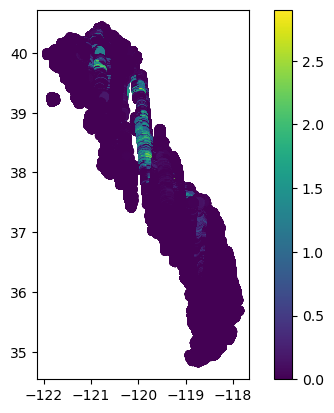

In [188]:
atl06sr_gdf.plot(column='reanalysis_sd', legend=True)

<Axes: >

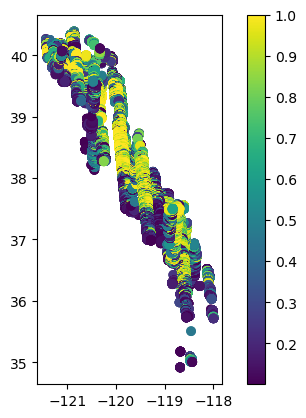

In [11]:
atl06sr_gdf[atl06sr_gdf['reanalysis_fsca']>0.1].plot(column='reanalysis_fsca', legend=True)

### Sample the reanalysis snow depth at IS2 points on corresponding dates:

In [17]:
# 2021:

for date_index in atl06sr_gdf['dowy'].unique():
    reanalysis = reanalysis_2021.SD_Post[date_index-1]
    x_coord = [pt.x for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    y_coord = [pt.y for pt in atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index)].to_crs('epsg:4326').geometry]
    atl06sr_gdf.loc[(atl06sr_gdf['dowy']==date_index), ['reanalysis_sd']] = reanalysis.sel(x=x_coord, y=y_coord, method='nearest').values.diagonal().T
    print('sampling date:', f'{date_index}')

sampling date: 12
sampling date: 9
sampling date: 8
sampling date: 5
sampling date: 4
sampling date: 365
sampling date: 361
sampling date: 353
sampling date: 352
sampling date: 349
sampling date: 348
sampling date: 341
sampling date: 340
sampling date: 337
sampling date: 336
sampling date: 332
sampling date: 320
sampling date: 319
sampling date: 316
sampling date: 315
sampling date: 312
sampling date: 311
sampling date: 308
sampling date: 307
sampling date: 303
sampling date: 291
sampling date: 290
sampling date: 287
sampling date: 286
sampling date: 283
sampling date: 282
sampling date: 279
sampling date: 278
sampling date: 275
sampling date: 270
sampling date: 263
sampling date: 261
sampling date: 259
sampling date: 257
sampling date: 255
sampling date: 253
sampling date: 251
sampling date: 249
sampling date: 247
sampling date: 245
sampling date: 241
sampling date: 232
sampling date: 230
sampling date: 228
sampling date: 226
sampling date: 224
sampling date: 222
sampling date: 220
sa

### Save the file:

In [18]:
atl06sr_gdf.to_pickle('../data/temp/atl06_sr_10m_sierras_concat_sorted_processed.pkl')